In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from facenet_pytorch import InceptionResnetV1
import torchvision.transforms as transforms
from PIL import Image

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [4]:
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

In [5]:
DATASET_PATH = r"C:\Users\USER\AI intern dataset\Images"

In [6]:
def prepare_dataset(dataset_path, split_ratio=0.8):
    train_data = []
    eval_data = []

    identities = os.listdir(dataset_path)

    for person in identities:
        person_path = os.path.join(dataset_path, person)
        if not os.path.isdir(person_path):
            continue

        for quality in ["high_quality", "low_quality"]:
            quality_path = os.path.join(person_path, quality)
            if not os.path.exists(quality_path):
                continue

            images = [
                os.path.join(quality_path, img)
                for img in os.listdir(quality_path)
                if img.lower().endswith(('.jpg', '.png', '.jpeg'))
            ]

            if len(images) < 2:
                continue

            train_imgs, eval_imgs = train_test_split(
                images,
                test_size=(1 - split_ratio),
                random_state=42
            )

            for img in train_imgs:
                train_data.append((img, person))

            for img in eval_imgs:
                eval_data.append((img, person))

    return train_data, eval_data


train_data, eval_data = prepare_dataset(DATASET_PATH)

print("Training images:", len(train_data))
print("Evaluation images:", len(eval_data))

Training images: 17822
Evaluation images: 4464


In [7]:
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [8]:
def get_embedding(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = model(img)

        return embedding.cpu().numpy()[0]
    except:
        return None

In [9]:
eval_embeddings = []
eval_labels = []

for path, label in tqdm(eval_data):
    emb = get_embedding(path)
    if emb is not None:
        eval_embeddings.append(emb)
        eval_labels.append(label)

eval_embeddings = np.array(eval_embeddings)

print("Valid evaluation embeddings:", len(eval_embeddings))

100%|██████████████████████████████████████████████████████████████████████████████| 4464/4464 [06:30<00:00, 11.42it/s]

Valid evaluation embeddings: 4436


In [10]:
norm_embeddings = eval_embeddings / np.linalg.norm(eval_embeddings, axis=1, keepdims=True)
similarity_matrix = np.dot(norm_embeddings, norm_embeddings.T)

similarities = []
ground_truth = []

n = len(eval_labels)

for i in range(n):
    for j in range(i + 1, n):
        similarities.append(similarity_matrix[i, j])
        ground_truth.append(1 if eval_labels[i] == eval_labels[j] else 0)

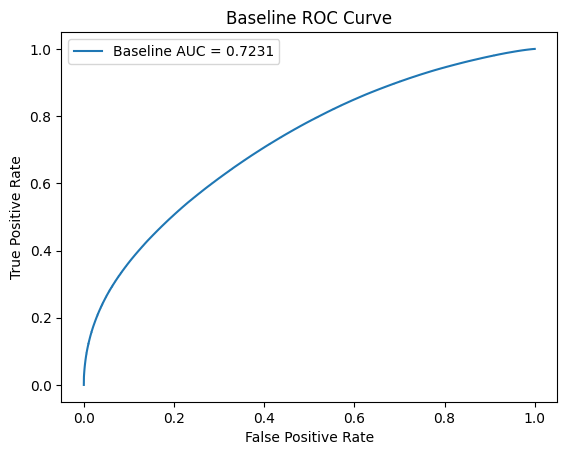

Baseline ROC AUC: 0.7231124576725899


In [11]:
fpr, tpr, _ = roc_curve(ground_truth, similarities)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Baseline AUC = {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline ROC Curve")
plt.legend()
plt.show()

print("Baseline ROC AUC:", roc_auc)

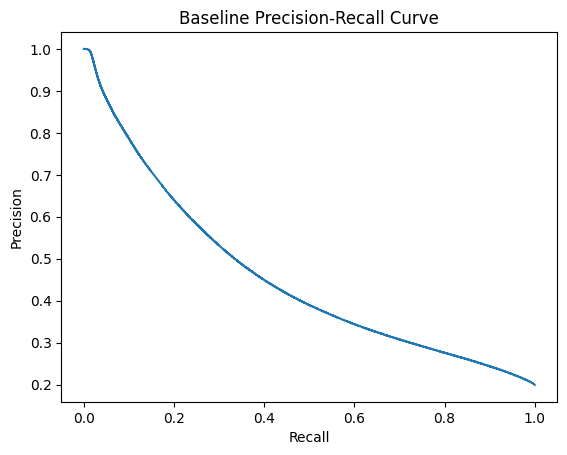

In [12]:
precision, recall, _ = precision_recall_curve(ground_truth, similarities)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Baseline Precision-Recall Curve")
plt.show()

In [13]:
unique_labels = sorted(list(set([label for _, label in train_data])))
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
num_classes = len(unique_labels)

print("Number of identities:", num_classes)

Number of identities: 8


In [14]:
valid_train_data = []

for path, label in train_data:
    try:
        img = Image.open(path).convert('RGB')
        valid_train_data.append((path, label))
    except:
        continue

print("Original train size:", len(train_data))
print("Valid train size:", len(valid_train_data))

Original train size: 17822
Valid train size: 17696


In [15]:
from torch.utils.data import Dataset, DataLoader

class FaceDataset(Dataset):
    def __init__(self, data_list):
        self.data_list = data_list

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        img = Image.open(img_path).convert('RGB')
        img = transform(img)
        label_idx = label_to_index[label]
        return img, label_idx

In [16]:
train_dataset = FaceDataset(valid_train_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [17]:
import torch.nn as nn

finetune_model = InceptionResnetV1(pretrained='vggface2').to(device)

# Freeze backbone except last layers
for param in finetune_model.parameters():
    param.requires_grad = False

for param in finetune_model.last_linear.parameters():
    param.requires_grad = True

classifier = nn.Linear(512, num_classes).to(device)

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(finetune_model.last_linear.parameters()) +
    list(classifier.parameters()),
    lr=1e-4
)

num_epochs = 20

In [19]:
best_loss = float('inf')

for epoch in range(num_epochs):
    finetune_model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        embeddings = finetune_model(images)
        outputs = classifier(embeddings)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'backbone': finetune_model.state_dict(),
            'classifier': classifier.state_dict()
        }, "best_model.pth")

Epoch [1/20] Loss: 1.6716
Epoch [2/20] Loss: 1.2529
Epoch [3/20] Loss: 1.0712
Epoch [4/20] Loss: 0.9613
Epoch [5/20] Loss: 0.8918
Epoch [6/20] Loss: 0.8506
Epoch [7/20] Loss: 0.8067
Epoch [8/20] Loss: 0.7965
Epoch [9/20] Loss: 0.7710
Epoch [10/20] Loss: 0.7648
Epoch [11/20] Loss: 0.7563
Epoch [12/20] Loss: 0.7399
Epoch [13/20] Loss: 0.7230
Epoch [14/20] Loss: 0.7195
Epoch [15/20] Loss: 0.7127
Epoch [16/20] Loss: 0.7109
Epoch [17/20] Loss: 0.7074
Epoch [18/20] Loss: 0.6886
Epoch [19/20] Loss: 0.6818
Epoch [20/20] Loss: 0.6854


In [20]:
checkpoint = torch.load("best_model.pth")

finetune_model.load_state_dict(checkpoint['backbone'])
classifier.load_state_dict(checkpoint['classifier'])

finetune_model.eval()

InceptionResnetV1(
  (conv2d_1a): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2a): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2b): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_4a): 

In [21]:
def get_finetuned_embedding(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = finetune_model(img)

        return embedding.cpu().numpy()[0]
    except:
        return None

In [22]:
new_eval_embeddings = []
new_eval_labels = []

for path, label in tqdm(eval_data):
    emb = get_finetuned_embedding(path)
    if emb is not None:
        new_eval_embeddings.append(emb)
        new_eval_labels.append(label)

new_eval_embeddings = np.array(new_eval_embeddings)

print("Fine-tuned evaluation embeddings:", len(new_eval_embeddings))

100%|██████████████████████████████████████████████████████████████████████████████| 4464/4464 [02:09<00:00, 34.39it/s]

Fine-tuned evaluation embeddings: 4436


In [23]:
norm_embeddings = new_eval_embeddings / np.linalg.norm(new_eval_embeddings, axis=1, keepdims=True)
similarity_matrix = np.dot(norm_embeddings, norm_embeddings.T)

new_similarities = []
new_ground_truth = []

n = len(new_eval_labels)

for i in range(n):
    for j in range(i + 1, n):
        new_similarities.append(similarity_matrix[i, j])
        new_ground_truth.append(1 if new_eval_labels[i] == new_eval_labels[j] else 0)

In [24]:
from sklearn.metrics import roc_curve, auc

fpr2, tpr2, _ = roc_curve(new_ground_truth, new_similarities)
roc_auc2 = auc(fpr2, tpr2)

print("Fine-tuned ROC AUC:", roc_auc2)

Fine-tuned ROC AUC: 0.8594557003573049


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


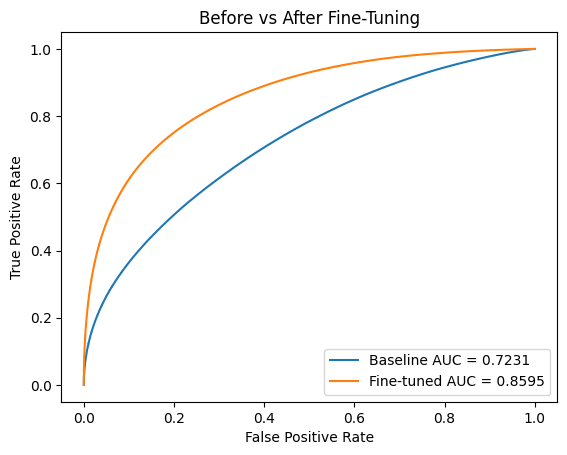

In [25]:
plt.figure()
plt.plot(fpr, tpr, label=f"Baseline AUC = {roc_auc:.4f}")
plt.plot(fpr2, tpr2, label=f"Fine-tuned AUC = {roc_auc2:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Before vs After Fine-Tuning")
plt.legend()
plt.show()

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision2, recall2, _ = precision_recall_curve(new_ground_truth, new_similarities)
ap2 = average_precision_score(new_ground_truth, new_similarities)

print("Fine-tuned Average Precision:", ap2)

Fine-tuned Average Precision: 0.6673833126198474


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


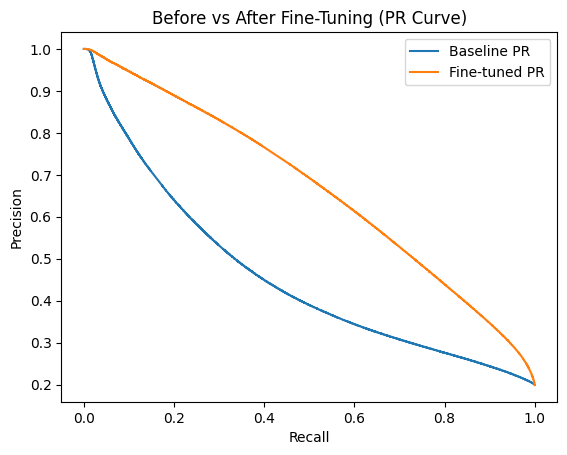

In [27]:
plt.figure()
plt.plot(recall, precision, label="Baseline PR")
plt.plot(recall2, precision2, label="Fine-tuned PR")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Before vs After Fine-Tuning (PR Curve)")
plt.legend()
plt.show()


In [31]:
def get_finetuned_embedding(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            embedding = finetune_model(img)

        return embedding.cpu().numpy()[0]

    except Exception as e:
        print("Embedding error for:", image_path)
        print("Actual error:", e)
        return None


In [32]:
img_high = "C:/Users/USER/AI intern dataset/Images/mujeeb/High_quality/frame0_face1.jpg"
img_low  = "C:/Users/USER/AI intern dataset/Images/mujeeb/Low_quality/b (112).png"

compare_two_images(img_high, img_low)


NameError: name 'compare_two_images' is not defined